In [2]:
import numpy as np
from scipy.interpolate import RegularGridInterpolator
from scipy.io import loadmat
import matplotlib.pyplot as plt
from skimage.transform import iradon
from tqdm import tqdm
from joblib import Parallel, delayed
import time
import cv2
import math
import pickle
from collections import defaultdict

constants

In [3]:
figures_path = "/Users/piotrblaszyk/Documents/university/MRIGI/med-surg-imaging-70003/cw/figures/"
code_path = "/Users/piotrblaszyk/Documents/university/MRIGI/med-surg-imaging-70003/cw/code/"
show_all_slices = False
compute_all_slices = False
compute_axial_reconstruction = False
compute_helical_sinograms = False

utility functions

In [4]:
def show_gray_img(img):
    plt.figure()
    plt.imshow(img, cmap='gray', origin='lower')
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    plt.close()

def rotate(img, angle, crop=True):
    (h,w)=img.shape[:2]
    angle_rad=np.deg2rad(angle)
    center=(w//2,h//2)
    rotation_matrix=cv2.getRotationMatrix2D(center,angle,1.0)
    if not crop:
        new_w=int(abs(w*np.cos(angle_rad))+abs(h*np.sin(angle_rad)))
        new_h=int(abs(w*np.sin(angle_rad))+abs(h*np.cos(angle_rad)))
        rotation_matrix[0,2]+=(new_w-w)/2
        rotation_matrix[1,2]+=(new_h-h)/2
    else:
        new_w = w
        new_h = h
    return cv2.warpAffine(img,rotation_matrix,(new_w, new_h))

def interpolate(arr, i):
    if i < 0 or i > len(arr) - 1:
        raise Exception(f"Index {i} out of bounds for array size {len(arr)}")
    a = math.floor(i)
    b = math.ceil(i)
    if a == b and int(a) == a:
        return arr[int(a)]
    assert b == a + 1, f"{b} != {a} + 1"
    return abs(i - a) * arr[a] + abs(b - i) * arr[b]

load CT projection dataset

In [5]:
ct_projections_path = '/Users/piotrblaszyk/Documents/university/MRIGI/med-surg-imaging-70003/tutorials/msi-2-tutorial-m/CT projections.mat'
mat_data = loadmat(ct_projections_path)
axial_sinograms = mat_data['projections']
print("Axial dataset shape:", axial_sinograms.shape)
n_slices, n_detectors, n_angles = axial_sinograms.shape

Axial dataset shape: (190, 380, 180)


reconstruct

In [6]:
axial_reconstructions_filename = f"{code_path}axial_reconstructions.pkl"
if compute_axial_reconstruction:
    axial_reconstructions = np.zeros((n_slices, n_detectors, n_detectors))
    for i in tqdm(range(n_slices)):
        theta = np.linspace(0, n_angles, n_angles, endpoint=False)
        axial_reconstructions[i] = iradon(axial_sinograms[i, :, :], theta=theta, filter_name="hann", circle=True)
    with open(axial_reconstructions_filename, 'wb') as file:
        pickle.dump(axial_reconstructions, file)
else:
     with open(axial_reconstructions_filename, 'rb') as file:
        axial_reconstructions = pickle.load(file)

print(axial_reconstructions.shape)

(190, 380, 380)


-0.0012414015991504873 0.03451338003285026


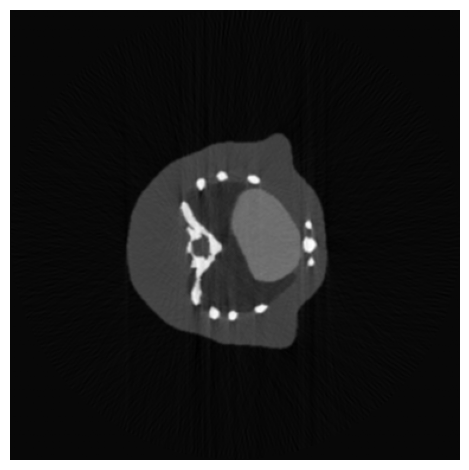

In [7]:
img = axial_reconstructions[109]
print(np.min(img), np.max(img))
show_gray_img(img)

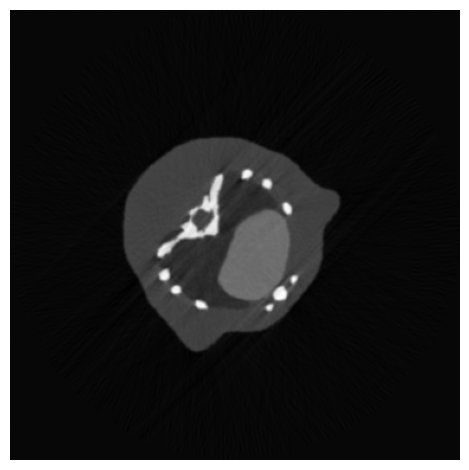

In [8]:
show_gray_img(rotate(img, angle=45))

compute helical sinograms (mine)

In [9]:
helical_sinograms_filename = f"{code_path}helical_sinograms.pkl"
num_table_movements = 19
num_detector_elements = 380
num_detector_rows = 10
num_projections_per_axial_scan = 180
pitch = 1.0
table_movement_per_half_rotation = num_detector_rows * pitch
total_z_length = num_table_movements * num_detector_rows
delta_z = table_movement_per_half_rotation / num_projections_per_axial_scan

if compute_helical_sinograms:
    delta_theta = 1
    z = 0
    theta = 0
    helical_sinograms = []
    with tqdm(total=total_z_length, desc="Processing") as pbar:
        while True:
            len_start = len(helical_sinograms)
            for k in range(num_detector_rows):
                z_detector_row = z + k
                if z_detector_row < total_z_length - 1:
                    slice_reconstructed = interpolate(axial_reconstructions, z_detector_row)
                    slice_reconstructed_rotated = rotate(slice_reconstructed, theta)
                    projection_1d = np.mean(slice_reconstructed_rotated, axis=0)
                    helical_sinograms.append((theta, z_detector_row, projection_1d))
            len_end = len(helical_sinograms)
            if len_start == len_end:
                break
            z += delta_z
            theta += delta_theta
            theta %= 360
            pbar.update(math.floor(z) - pbar.n)
    helical_sinograms.sort(key=lambda item: (item[0], item[1]))
    with open(helical_sinograms_filename, 'wb') as file:
        pickle.dump(helical_sinograms, file)
else:
    with open(helical_sinograms_filename, 'rb') as file:
        helical_sinograms = pickle.load(file)

print(len(helical_sinograms))

33220


calculate helical sinogram for target slice

In [19]:
# slices: 0 - 189
# target slice = 109
# span: table_movement_per_half_rotation
# span / 2 : table_movement_per_half_rotation / 2
# centre: z_detector_row = 109
# obtain all angles 0 - 179
# minimise z_detector_row
# for each angle
# scan helical_sinograms, obtain projection _1d that minimises z_detector_row
# save to a numpy arr of shape: (180, 380, 380)
helical_sinogram_target_slice = np.zeros((num_projections_per_axial_scan, num_detector_elements))
foo = defaultdict(lambda: (float('inf'), -1))
target_slice = 109
for i in range(len(helical_sinograms)):
    theta, z_detector_row, projection_1d = helical_sinograms[i]
    foo_dist, j = foo[theta]
    cur_dist = abs(target_slice - z_detector_row)
    if cur_dist < foo_dist:
        foo[theta] = (cur_dist, i)

assert set(foo.keys()) == set(range(num_projections_per_axial_scan * 2)), f"Dict keys don't correspond to {min(range(num_projections_per_axial_scan))} - {max(range(num_projections_per_axial_scan * 2))}"
for i in range(num_projections_per_axial_scan):
    foo_dist, j = foo[i]
    theta, z_detector_row, projection_1d = helical_sinograms[i]
    helical_sinogram_target_slice[i] = projection_1d

helical_sinogram_target_slice = helical_sinogram_target_slice.T
assert helical_sinogram_target_slice.shape == (num_detector_elements, num_projections_per_axial_scan), f"helical_sinogram_target_slice's shape isn't appropriate for iradon to accept"

reconstruct helical target slice

In [20]:
theta = np.linspace(0, num_projections_per_axial_scan, num_projections_per_axial_scan, endpoint=False)
helical_reconstruction = iradon(helical_sinogram_target_slice, theta=theta, filter_name="hann", circle=True)

show helical target slice

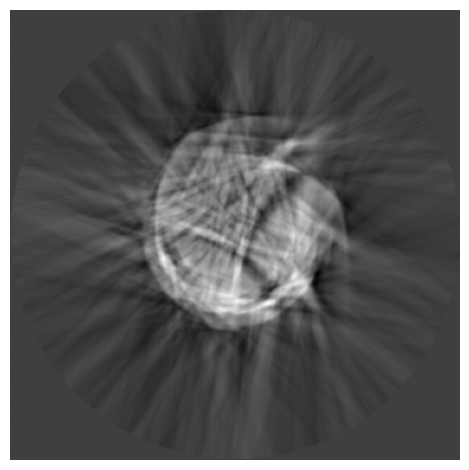

In [21]:
show_gray_img(helical_reconstruction)